In [1]:
from aniposelib.cameras import CameraGroup, Camera
import numpy as np
import h5py
import glob
import os

In [2]:
# cam 1

K1 = np.array([[2.72631380e+03, 0.00000000e+00, 9.57747448e+02],
[0.00000000e+00, 2.75788479e+03, 4.82921207e+02],
[0.00000000e+00, 0.00000000e+00, 1.00000000e+00]])
distortion1 = np.array([ 6.09422782e-02,  1.03365973e+00,  1.34003666e-02,  1.75159685e-03,
-2.80586518e+00])

R1 = np.array([[ 0.28697741],
[ 0.00382006],
[-0.00138285]])
t1 = np.array([[ 0.09598585],
[-0.5431292 ],
[23.84214207]])

In [3]:
# Camera 2  
K2 = np.array([[3.54548296e+03, 0.00000000e+00, 9.60287866e+02],
[0.00000000e+00, 3.54924565e+03, 5.57450277e+02],
[0.00000000e+00, 0.00000000e+00, 1.00000000e+00]])
distortion2 = np.array([ 5.22080106e-02,  5.61495738e+00,  1.01498704e-02,  2.81631980e-03,
-2.88237239e+01])

R2 = np.array([[0.09831322],
        [2.50218118],
        [0.27399503]])
t2 = np.array([[-0.71703402],
        [-0.05154335],
        [33.4177848 ]])

In [4]:
# Camera 3 
K3 = np.array([[3.25847386e+03, 0.00000000e+00, 9.22522896e+02],
[0.00000000e+00, 3.27790661e+03, 5.28108833e+02],
[0.00000000e+00, 0.00000000e+00, 1.00000000e+00]])
distortion3 = np.array([ 7.77164572e-02,  2.92914065e+00,  6.95976175e-04, -2.49305655e-03,
-1.37181983e+01])

R3 = np.array([[ 0.06493758],
[-2.48289991],
[-0.29989151]])
t3 = np.array([[ 1.14692637],
[-0.50242494],
[30.37349303]])


In [5]:
# load calib parameters
camera_matrices = [K1, K2, K3]
dist_coeffs = [distortion1, distortion2, distortion3]
rvecs = [R1, R2, R3]
tvecs = [t1, t2, t3]

cameras = []
for i in range(3):
    cam = Camera(
        matrix=camera_matrices[i],
        dist=dist_coeffs[i],
        rvec=rvecs[i],
        tvec=tvecs[i],
        name=f'cam{i+1}'
    )
    cameras.append(cam)

cgroup = CameraGroup(cameras)
cgroup

In [6]:
# load 2d coords

# path
rootdir = '/Volumes/THANH/IceSkating/2d_coords/interpolated_coords'
# rootdir = r'\\tsclient\thesis'
video_files = sorted(glob.glob(os.path.join(rootdir, 'cam*.h5')))

data = {}
for video_file in video_files:
    with h5py.File(video_file,'r') as f:
        data[video_file] = {
            "coords" : f["coords_39"][:],
        }

In [58]:
cam_keys = data.keys()
coords = []
for i,cam in enumerate(cam_keys):
    arr = data[cam]['coords'].transpose(1,3,2,0)
    coords.append(arr)
coords # (3,4200,17,2,39)
n_vids = coords[0].shape[3]
n_frames = coords[0].shape[0]
n_joints = coords[0].shape[1]

In [43]:
constraints = [
    [5, 7],    # left upper arm
    [7, 9],    # left forearm

    [6, 8],    # right upper arm
    [8, 10],   # right forearm

    [11, 13],  # left thigh
    [13, 15],  # left shin

    [12, 14],  # right thigh
    [14, 16],  # right shin

    [5, 6],    # shoulder width
    [11, 12],  # hip width

    [5, 11],   # left torso
    [6, 12],   # right torso
]

In [61]:
all_3d = np.zeros((n_vids,n_frames,n_joints,3))
for chunk in range(n_vids):
    p1 = coords[0][:,:,:,chunk]
    p2 = coords[1][:,:,:,chunk]
    p3 = coords[2][:,:,:,chunk]
    points = np.stack([p1, p2, p3], axis=0)

    n_cams, n_frames, n_joints, _ = points.shape
    points_2d_flat = points.reshape(n_cams, n_frames * n_joints, 2)
    points_3d = cgroup.triangulate(points_2d_flat, progress=True)
    points_3d = points_3d.reshape(n_frames,n_joints,3)
    all_3d[chunk,:,:,:] = points_3d

100%|████████████████████████| 71400/71400 [00:04<00:00, 14380.20it/s]


In [ ]:
all_3d = np.zeros((n_vids,n_frames,n_joints,3))
for chunk in range(n_vids):
    p1 = coords[0][:,:,:,chunk]
    p2 = coords[1][:,:,:,chunk]
    p3 = coords[2][:,:,:,chunk]
    points = np.stack([p1, p2, p3], axis=0)

    points_3d = cgroup.triangulate_optim(
        points,
        constraints=constraints,
        scale_smooth=4,
        scale_length=2)
    
    all_3d[chunk,:,:,:] = points_3d

In [ ]:
all_3d = np.zeros(n_vids,n_frames,n_joints,3)
for chunk in range(n_vids):
    p1 = coords[0][:,:,:,chunk]
    p2 = coords[1][:,:,:,chunk]
    p3 = coords[2][:,:,:,chunk]
    points = np.stack([p1, p2, p3], axis=0)

    n_cams, n_frames, n_joints, _ = points.shape
    points_2d_flat = points.reshape(n_cams, n_frames * n_joints, 2)
    points_3d = cgroup.triangulate(points_2d_flat, progress=True)
    all_3d[chunk,:,:,:] = points_3d

In [ ]:
from scipy.signal import savgol_filter
from scipy.interpolate import interp1d

points_3d_clean = np.copy(points_3d)

for joint in range(n_joints):
    for coord in range(3):
        y = points_3d[:, joint, coord]
        nan_mask = np.isnan(y)
        
        # interpolate NaN gaps
        if nan_mask.any() and (~nan_mask).sum() >= 2:
            good_idx = np.where(~nan_mask)[0]
            f = interp1d(good_idx, y[good_idx], kind='cubic', fill_value='extrapolate')
            points_3d_clean[nan_mask, joint, coord] = f(np.where(nan_mask)[0])
        
        # smooth with SG
        points_3d_clean[:, joint, coord] = savgol_filter(
            points_3d_clean[:, joint, coord], 
            window_length=25, polyorder=3
        )

Camera 0: grabbed frame 1300, shape: (1080, 1920, 3)
Camera 1: grabbed frame 1300, shape: (1080, 1920, 3)
Camera 2: grabbed frame 1300, shape: (1080, 1920, 3)


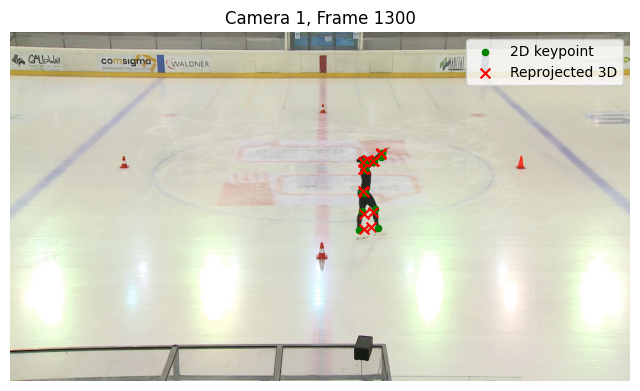

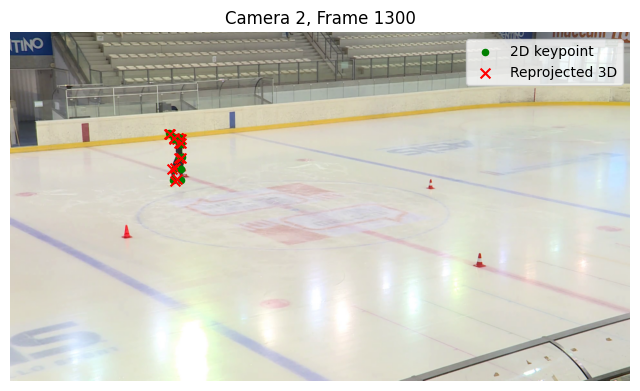

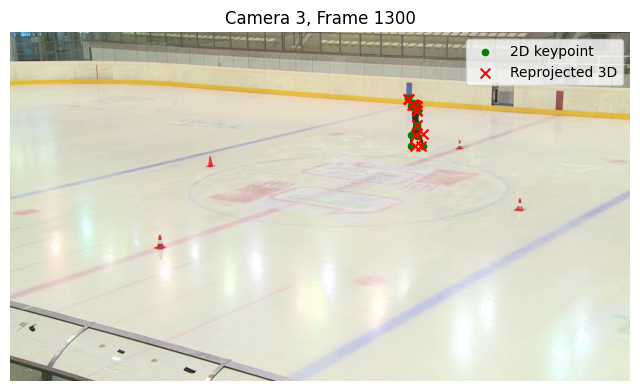

In [16]:
# reproject on frame 100th 
import cv2
import matplotlib.pyplot as plt 

path = '/Volumes/THANH/IceSkating/experiment/stimuli'
video_files = sorted(glob.glob(os.path.join(path, '*.mp4')))

frame_idx = 1300
frames_sample = []


for i, video_file in enumerate(video_files):
        cap = cv2.VideoCapture(video_file)
        
        # Set to the desired frame index
        cap.set(cv2.CAP_PROP_POS_FRAMES, frame_idx)
        
        ret, frame = cap.read()
        if not ret:
            print(f"Failed to read frame {frame_idx} from camera {i}")
            frame = None
        frames_sample.append(frame)  # store the frame
        
        cap.release()
        if frame is not None:
            print(f"Camera {i}: grabbed frame {frame_idx}, shape: {frame.shape}")
for cam_idx in range(3):
        frame = frames_sample[cam_idx]
        if frame is None:
            continue
        
        plt.figure(figsize=(8,6))
        plt.imshow(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
        
        for j in range(17):
            # original 2D keypoint
            x2d = kpts[cam_idx][frame_idx, j, :]
            plt.scatter(x2d[0], x2d[1], c='g', s=20, label='2D keypoint' if j==0 else "")
            
            # reproject using anipose camera
            X3d = points_3d_clean[frame_idx, j, :]
            if np.any(np.isnan(X3d)):
                continue
            
            x_proj = cgroup.cameras[cam_idx].project(X3d.reshape(1, 3)).flatten()
            plt.scatter(x_proj[0], x_proj[1], c='r', s=50, marker='x', label='Reprojected 3D' if j==0 else "")

        plt.title(f"Camera {cam_idx+1}, Frame {frame_idx}")
        plt.legend(loc='upper right')
        plt.axis('off')
        plt.show()
